# Carbon-intensity dataset inspection

The forecasting experiments read one series: the Electricity Maps **actual**
carbon intensity of the Italian North bidding zone (`IT-NO`), cached as
`data/carbon_intensity/actual/actual.json` on a 15-minute UTC grid.
This notebook inspects that series alone - it fits nothing and writes nothing.

The questions it answers, in order: is the cache complete and trustworthy, how
does the level move across the years and inside each year, what seasonal and
daily structure it carries, and how predictable it actually is at the horizons
the scheduler needs.

In [8]:
from datetime import timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

from carbon_intensity.protocol import TemporalProtocol
from carbon_intensity.series import TimeSeriesCarbonIntensityProvider


PROJECT_ROOT = Path("../").resolve()
print(f"Project root: {PROJECT_ROOT}")
ACTUAL_PATH = PROJECT_ROOT / "data" / "carbon_intensity" / "actual" / "actual.json"
PROTOCOL_PATH = ACTUAL_PATH.parent / "protocol.json"
UNIT = "gCO2eq/kWh"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
YEAR_COLORS = dict(zip(range(2016, 2021), plt.get_cmap("viridis")(np.linspace(0.05, 0.85, 5))))
SPLIT_COLORS = {"train": "#B8D8E3", "validation": "#F2C57C", "test": "#E58F8F"}
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")




provider = TimeSeriesCarbonIntensityProvider.load(ACTUAL_PATH)
protocol = TemporalProtocol.load(PROTOCOL_PATH)

ci = pd.Series(
    [sample.intensity_gco2e_per_kwh for sample in provider.samples],
    index=pd.DatetimeIndex(
        [sample.timestamp for sample in provider.samples], name="timestamp"
    ),
    name="intensity",
)
frame = pd.DataFrame({
    "intensity": ci,
    "year": ci.index.year,
    "month": ci.index.month,
    "hour": ci.index.hour + ci.index.minute / 60,
    "weekday": ci.index.weekday,
    "dayofyear": ci.index.dayofyear,
})
daily = ci.resample("D").mean()
hourly = ci.resample("h").mean()

print(f"{len(ci):,} buckets from {ci.index[0]} to {ci.index[-1] + timedelta(minutes=15)}")
ci.describe().to_frame(UNIT)

Project root: /Users/alberto/Desktop/Repositories/Carbon-aware HPC
169,536 buckets from 2016-01-01 00:00:00+00:00 to 2020-11-01 00:00:00+00:00


,gCO2eq/kWh
count,"169,536.00"
mean,356.26
std,84.36
min,133.00
25%,295.00
50%,348.00
75%,413.00
max,667.00


## 1. Provenance and split boundaries

The metadata travels with the cache, so the signal, zone and emission-factor
convention are read back rather than assumed. The splits come from
`protocol.json`: the test window is exactly the span the PM100 workload touches.

In [9]:
metadata = provider.metadata
provenance = pd.Series({
    key: metadata[key]
    for key in (
        "source", "api_version", "endpoint", "signal", "zone", "unit",
        "temporal_granularity", "emission_factor_type", "flow_traced",
        "methodology_note",
    )
}, name="value").to_frame()

splits = pd.DataFrame(
    [
        {
            "partition": name,
            "start": start,
            "end": end,
            "buckets": len(ci.loc[(ci.index >= start) & (ci.index < end)]),
            "days": (end - start) / timedelta(days=1),
            "mean": ci.loc[(ci.index >= start) & (ci.index < end)].mean(),
        }
        for name, (start, end) in protocol.intervals.items()
    ]
).set_index("partition")

display(provenance)
display(splits)
print(
    "Buckets after the test window (unused by the protocol): "
    f"{(ci.index >= protocol.test_end).sum():,}"
)

,value
source,Electricity Maps API
api_version,v4
endpoint,/carbon-intensity/past-range
signal,actual carbon intensity
zone,IT-NO
unit,gCO2eq/kWh
temporal_granularity,15_minutes
emission_factor_type,lifecycle
flow_traced,True
methodology_note,Matching API parameters; no historical methodo...


,start,end,buckets,days,mean
partition,,,,,
train,2016-01-01 00:00:00+00:00,2020-01-01 00:00:00+00:00,140256,"1,461.00",370.32
validation,2020-01-01 00:00:00+00:00,2020-05-06 07:00:00+00:00,12124,126.29,296.12
test,2020-05-06 07:00:00+00:00,2020-10-13 05:00:00+00:00,15352,159.92,284.99


Buckets after the test window (unused by the protocol): 1,804


Lifecycle, flow-traced actuals for a single zone. The cache runs three weeks
past the end of the test window; those buckets are carried by the file but no
split claims them.

## 2. Completeness and data quality

A gap in this series would silently become a gap in every forecast feature, so
it is checked against a dense 15-minute grid rather than trusted.

In [10]:
expected = pd.date_range(ci.index[0], ci.index[-1], freq="15min", tz="UTC")
estimated = pd.Series(
    [sample.is_estimated for sample in provider.samples], index=ci.index
)
methods = pd.Series(
    [sample.estimation_method or "measured" for sample in provider.samples]
)

quality = pd.Series({
    "expected buckets": len(expected),
    "present buckets": len(ci),
    "missing buckets": len(expected.difference(ci.index)),
    "duplicate timestamps": int(ci.index.duplicated().sum()),
    "non-finite values": int((~np.isfinite(ci)).sum()),
    "negative values": int((ci < 0).sum()),
    "flagged estimated": int(estimated.fillna(False).sum()),
    "unlabelled provenance": int(estimated.isna().sum()),
    "integer-valued": int((ci == ci.round()).sum()),
}, name="count").to_frame()

display(quality)
display(methods.value_counts().rename("buckets").to_frame())

,count
expected buckets,169536
present buckets,169536
missing buckets,0
duplicate timestamps,0
non-finite values,0
negative values,0
flagged estimated,4
unlabelled provenance,0
integer-valued,169536


,buckets
measured,169532
TIME_SLICER_AVERAGE,4


No gaps, no duplicates, no missing provenance. Only 4 of ~170k buckets are
API-estimated (`TIME_SLICER_AVERAGE`), which is too few to matter. Every value
is a whole number: the API publishes rounded integers, so ~1 gCO2eq/kWh of
quantisation noise is the accuracy floor of anything fitted to it.

## 3. Effective resolution

The grid is 15-minute, but that is not the same as the data changing every 15
minutes. Counting hours whose four buckets hold a single value shows how much
of the "15-minute" series is really hourly data repeated.

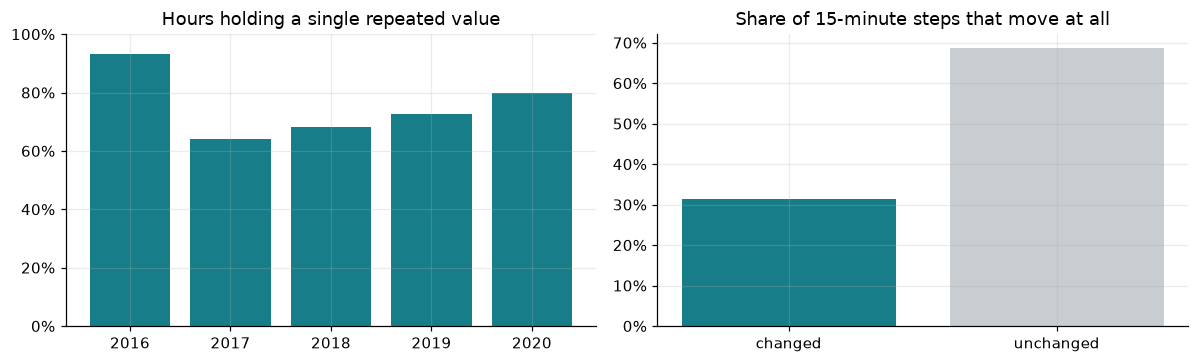

Overall share of hours with one distinct value: 75.5%


In [11]:
distinct_per_hour = ci.groupby(ci.index.floor("h")).nunique()
constant_share = distinct_per_hour.eq(1).groupby(distinct_per_hour.index.year).mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].bar(constant_share.index.astype(str), constant_share.values, color="#177E89")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].set_title("Hours holding a single repeated value")
axes[0].set_ylim(0, 1)
step = ci.diff().dropna()
axes[1].bar(
    ["changed", "unchanged"],
    [(step != 0).mean(), (step == 0).mean()],
    color=["#177E89", "#C7CDD1"],
)
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_title("Share of 15-minute steps that move at all")
fig.tight_layout()
plt.show()

print(f"Overall share of hours with one distinct value: {distinct_per_hour.eq(1).mean():.1%}")

Three quarters of the hours are flat, and only ~31% of 15-minute steps move,
with 2016 almost entirely hourly. The series carries roughly hourly
information on a 15-minute index; sub-hourly leads are therefore easy for the
wrong reason - the value has usually not been updated yet.

## 4. The whole series

Raw buckets behind a 7-day rolling mean, with the protocol splits shaded.

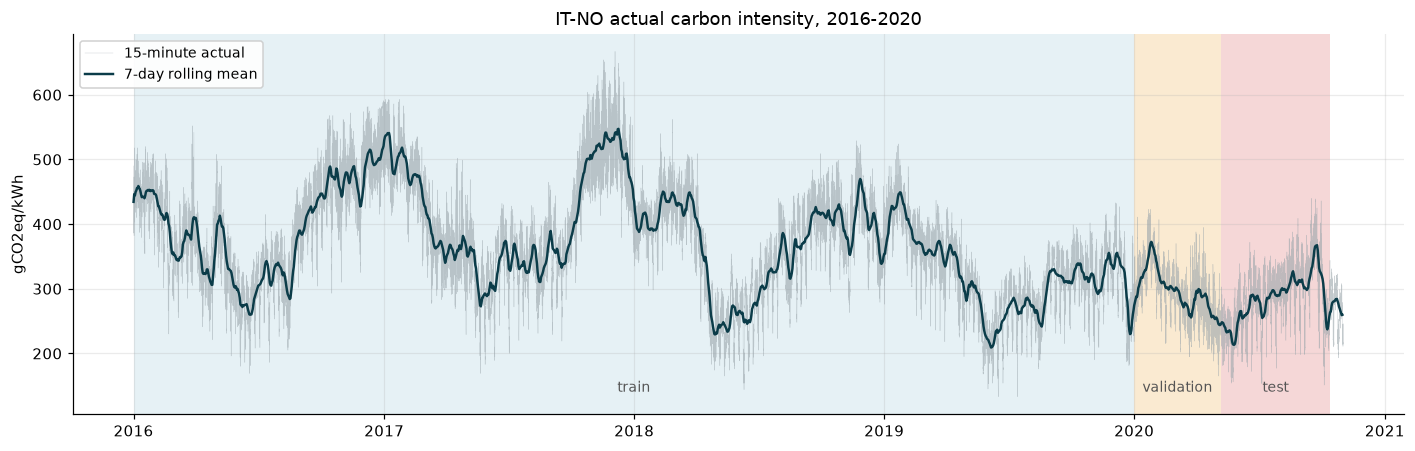

In [12]:
fig, ax = plt.subplots(figsize=(13, 4.2))
for name, (start, end) in protocol.intervals.items():
    ax.axvspan(start, end, color=SPLIT_COLORS[name], alpha=0.35, lw=0, zorder=0)
    ax.text(
        start + (end - start) / 2, ci.min() * 1.02, name,
        ha="center", va="bottom", fontsize=9, color="#555",
    )
ax.plot(ci.index, ci.values, lw=0.25, color="#9AA5AB", alpha=0.6, label="15-minute actual")
ax.plot(
    daily.index, daily.rolling(7, min_periods=1).mean(),
    lw=1.6, color="#0B3C49", label="7-day rolling mean",
)
ax.set_ylabel(UNIT)
ax.set_title("IT-NO actual carbon intensity, 2016-2020")
ax.legend(loc="upper left", framealpha=0.9, fontsize=9)
fig.tight_layout()
plt.show()

A falling level with a repeating within-year wave: high in winter, low around
midsummer. The test window sits in the lowest-intensity part of the record,
so the training years are not drawn from the same distribution as the scored
one - a level shift the models have to absorb.

## 5. Year over year

Distribution per calendar year, next to the annual mean. 2020 is partial
(January to October), which is why its summary is not directly comparable.

,buckets,mean,median,std,minimum,maximum,p05,p95,coverage
year,,,,,,,,,
2016,35136,392.40,391.00,79.31,169.00,591.00,264.00,517.00,1.00
2017,35040,406.65,389.00,87.41,169.00,667.00,281.00,561.00,1.00
2018,35040,364.29,381.00,74.74,144.00,562.00,223.00,467.00,1.00
2019,35040,317.87,318.00,62.39,133.00,524.00,215.00,423.00,1.00
2020,29280,288.90,290.00,46.73,151.00,440.00,210.00,365.00,0.84


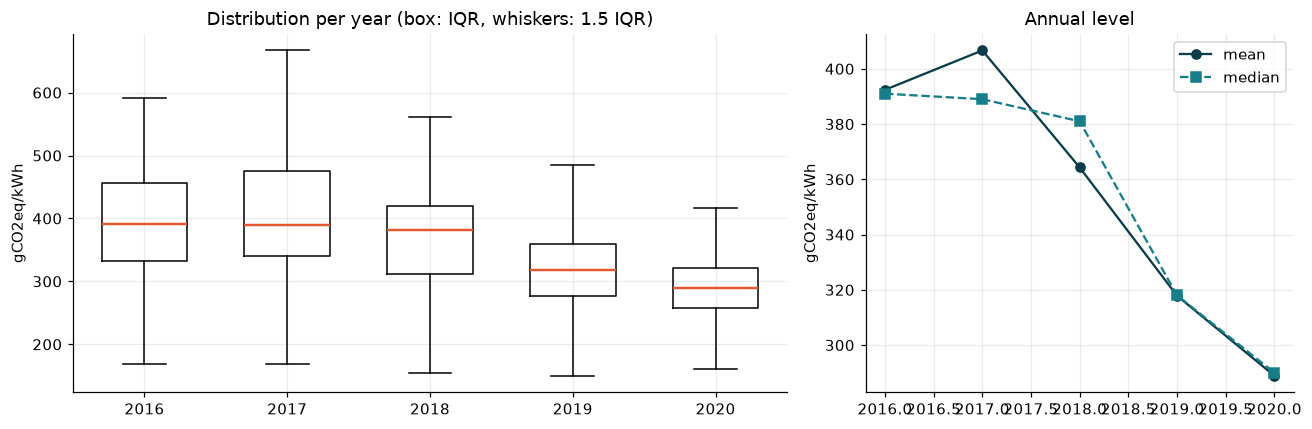

Mean 2016 -> 2020 (partial year): -26.4%


In [13]:
by_year = frame.groupby("year")["intensity"].agg(
    buckets="count", mean="mean", median="median", std="std", minimum="min", maximum="max",
)
by_year["p05"] = frame.groupby("year")["intensity"].quantile(0.05)
by_year["p95"] = frame.groupby("year")["intensity"].quantile(0.95)
by_year["coverage"] = by_year["buckets"] / (365.25 * 96)
display(by_year)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [2, 1.2]})
years = sorted(frame["year"].unique())
axes[0].boxplot(
    [frame.loc[frame["year"] == year, "intensity"] for year in years],
    tick_labels=[str(year) for year in years], showfliers=False, widths=0.6,
    medianprops={"color": "#E4572E", "lw": 1.6},
)
axes[0].set_ylabel(UNIT)
axes[0].set_title("Distribution per year (box: IQR, whiskers: 1.5 IQR)")
axes[1].plot(years, by_year["mean"], "o-", color="#0B3C49", label="mean")
axes[1].plot(years, by_year["median"], "s--", color="#177E89", label="median")
axes[1].set_title("Annual level")
axes[1].set_ylabel(UNIT)
axes[1].legend()
fig.tight_layout()
plt.show()

drop = 100 * (by_year.loc[2020, "mean"] - by_year.loc[2016, "mean"]) / by_year.loc[2016, "mean"]
print(f"Mean 2016 -> 2020 (partial year): {drop:.1f}%")

The mean falls from ~392 to ~289 gCO2eq/kWh, about -26% in five years, and the
spread narrows with it: the maximum drops from 591 to 440 while the minimum
barely moves. Grid decarbonisation is trimming the high-intensity tail, not
shifting the whole distribution down.

## 6. Inside each year

The same five years drawn separately on a shared axis, so the seasonal shape
can be compared without the trend stacking the curves on top of each other.

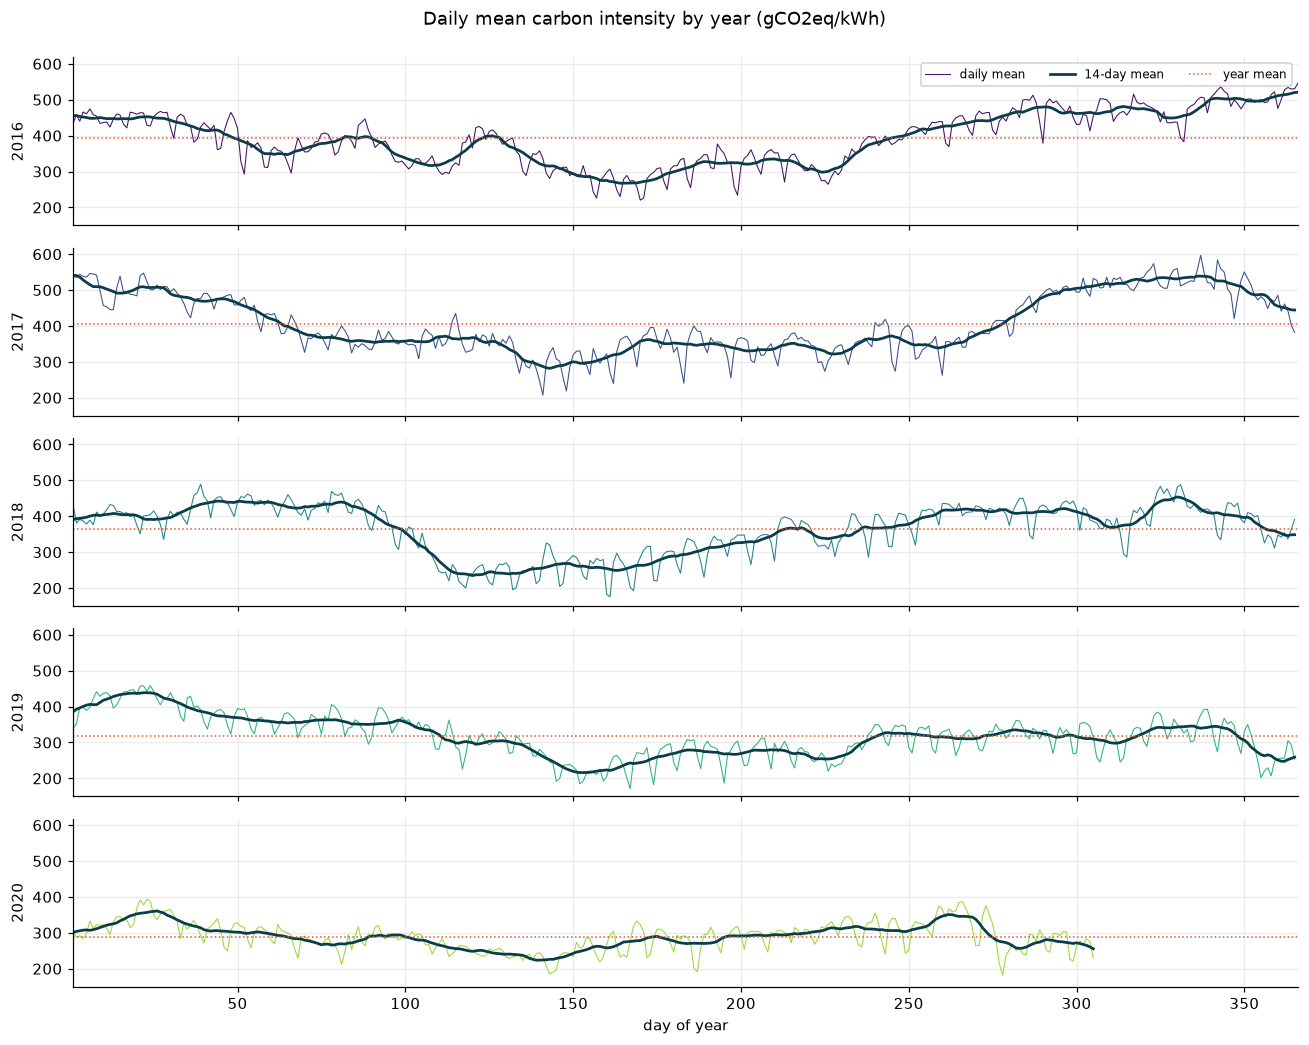

In [14]:
fig, axes = plt.subplots(len(years), 1, figsize=(12, 1.9 * len(years)), sharex=True, sharey=True)
for ax, year in zip(axes, years):
    year_daily = daily[daily.index.year == year]
    x = year_daily.index.dayofyear
    ax.plot(x, year_daily.values, lw=0.7, color=YEAR_COLORS[year], label="daily mean")
    ax.plot(
        x, year_daily.rolling(14, min_periods=1, center=True).mean(),
        lw=1.8, color="#0B3C49", label="14-day mean",
    )
    ax.axhline(year_daily.mean(), color="#E4572E", lw=1, ls=":", label="year mean")
    ax.set_ylabel(str(year))
    ax.set_xlim(1, 366)
axes[0].legend(loc="upper right", ncol=3, fontsize=8, framealpha=0.9)
axes[-1].set_xlabel("day of year")
fig.suptitle(f"Daily mean carbon intensity by year ({UNIT})", y=0.995)
fig.tight_layout()
plt.show()

Every year runs the same U: a winter plateau, a spring descent into a trough
in May or June, an autumn climb back. Measured on monthly means the wave is
worth 183-227 gCO2eq/kWh in the four complete years - roughly twice the entire
five-year downward trend - so season, not year, is the dominant source of
variation and a model without a calendar feature cannot separate the two.
(2020 shows only 100 because the record stops in October, before its peak.)

## 7. Season, day and week

A day-of-year by year heatmap places the seasonal wave and the trend on one
picture; the monthly and diurnal profiles then read the two cycles separately.

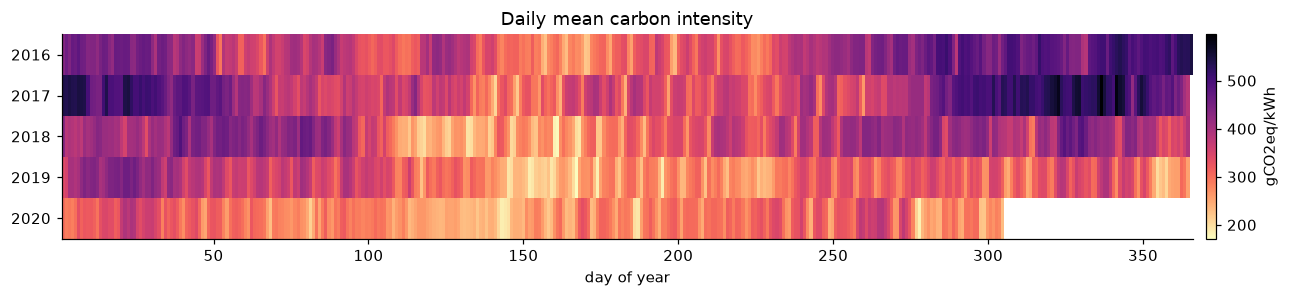

In [15]:
calendar = (
    daily.to_frame("intensity")
    .assign(year=daily.index.year, dayofyear=daily.index.dayofyear)
    .pivot(index="year", columns="dayofyear", values="intensity")
    .reindex(columns=range(1, 367))
)

fig, ax = plt.subplots(figsize=(13, 2.8))
mesh = ax.imshow(
    calendar.values, aspect="auto", cmap="magma_r", interpolation="nearest",
    extent=(1, 366, len(years) - 0.5, -0.5),
)
ax.set_yticks(range(len(years)), [str(year) for year in calendar.index])
ax.set_xlabel("day of year")
ax.grid(False)
ax.set_title("Daily mean carbon intensity")
fig.colorbar(mesh, ax=ax, label=UNIT, pad=0.01)
fig.tight_layout()
plt.show()

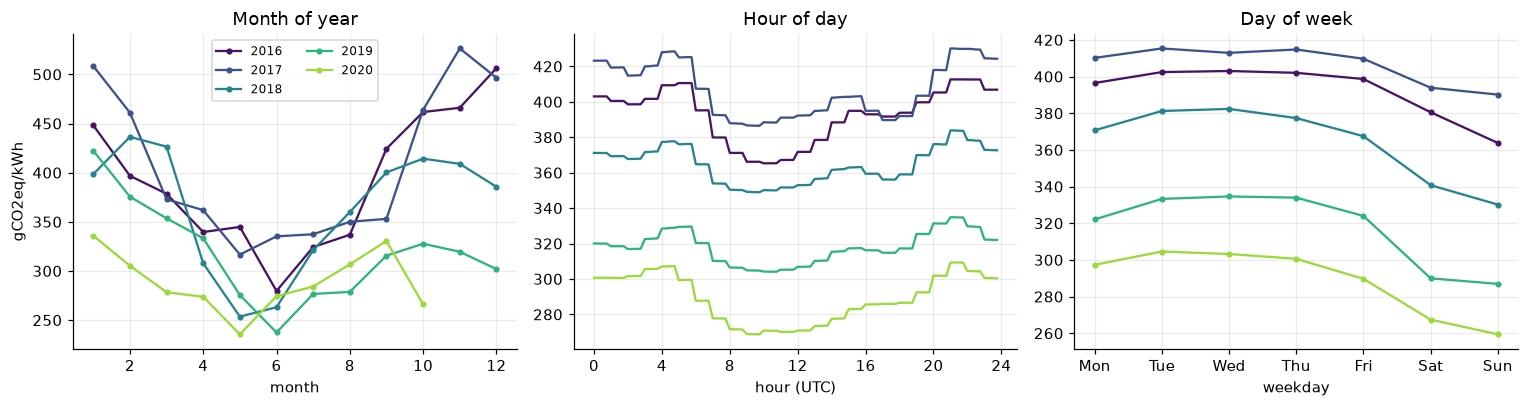

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for year in years:
    year_rows = frame[frame["year"] == year]
    axes[0].plot(
        year_rows.groupby("month")["intensity"].mean(),
        "o-", ms=3, color=YEAR_COLORS[year], label=str(year),
    )
    axes[1].plot(
        year_rows.groupby("hour")["intensity"].mean(),
        color=YEAR_COLORS[year], label=str(year),
    )
    axes[2].plot(
        year_rows.groupby("weekday")["intensity"].mean(),
        "o-", ms=3, color=YEAR_COLORS[year], label=str(year),
    )
axes[0].set(xlabel="month", ylabel=UNIT, title="Month of year")
axes[1].set(xlabel="hour (UTC)", title="Hour of day")
axes[1].set_xticks(range(0, 25, 4))
axes[2].set(xlabel="weekday", title="Day of week")
axes[2].set_xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[0].legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

The monthly curves are close to parallel: the same seasonal shape shifted down
each year. The daily cycle is comparatively small - a ~39 gCO2eq/kWh swing
against a seasonal one four to six times larger - and runs the opposite way to
demand: the cleanest hours are late morning (09-12 UTC) and the dirtiest lie
on a broad overnight plateau (21-05 UTC). Weekends are cleaner in every year,
by 20-40 gCO2eq/kWh.

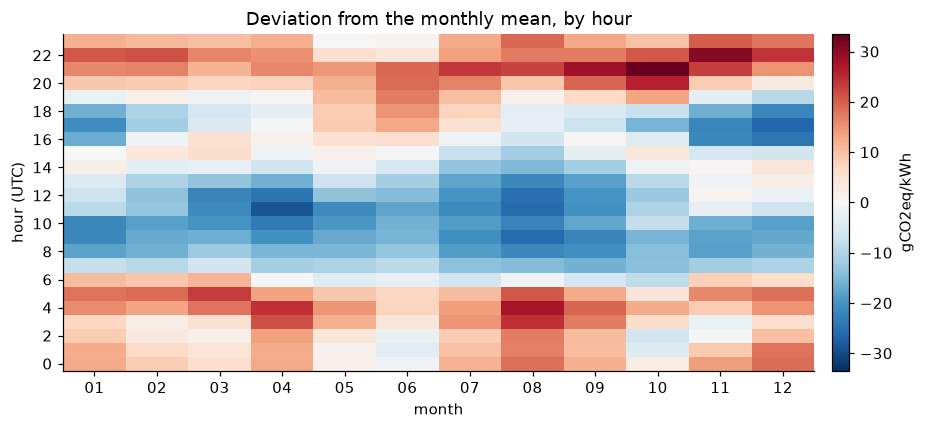

,amplitude,cleanest hour,dirtiest hour
month,,,
1,42.33,10,22
2,39.56,10,22
3,45.53,12,5
4,53.05,11,4
5,36.24,11,4
6,36.83,11,21
7,44.80,11,21
8,53.35,11,4
9,50.21,9,21


In [17]:
hour_month = frame.pivot_table(
    index=frame["hour"].astype(int), columns="month", values="intensity", aggfunc="mean"
)
# Centring each month on its own mean is what makes the daily shape visible:
# on raw values the seasonal level swamps a cycle four times smaller.
centred = hour_month - hour_month.mean(axis=0)
limit = np.abs(centred.values).max()

fig, ax = plt.subplots(figsize=(9, 4))
mesh = ax.imshow(
    centred.values, aspect="auto", cmap="RdBu_r", origin="lower", vmin=-limit, vmax=limit,
)
ax.set_xticks(range(12), [f"{m:02d}" for m in centred.columns])
ax.set_yticks(range(0, 24, 2))
ax.set(xlabel="month", ylabel="hour (UTC)", title="Deviation from the monthly mean, by hour")
ax.grid(False)
fig.colorbar(mesh, ax=ax, label=UNIT, pad=0.02)
fig.tight_layout()
plt.show()

display(
    pd.DataFrame({
        "amplitude": hour_month.max(axis=0) - hour_month.min(axis=0),
        "cleanest hour": hour_month.idxmin(axis=0),
        "dirtiest hour": hour_month.idxmax(axis=0),
    }).rename_axis("month")
)

The amplitude is roughly constant all year (36-53 gCO2eq/kWh), so the daily
cycle never disappears - what changes is its *shape*. From May to September
there is a single broad daytime trough, consistent with solar. From October to
April a second trough opens at 16-18 UTC and the profile becomes double-dipped,
which is why the cleanest hour of the day jumps from 11 to 17 UTC in the last
quarter. An hour-of-day feature is therefore only correct when interacted with
the month; used alone it averages two different shapes together.

## 8. Distribution shape

Whether the level shift is a translation or a change of shape decides how much
a model trained on 2016-2019 can transfer to 2020.

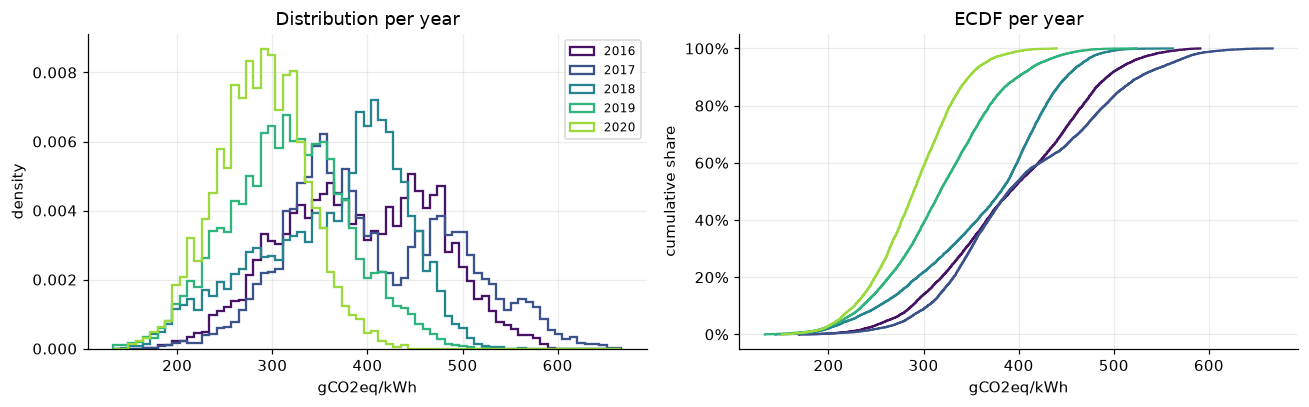

,skew,kurtosis,iqr
year,,,
2016,-0.05,-0.71,124.00
2017,0.30,-0.60,135.00
2018,-0.52,-0.48,108.00
2019,0.04,-0.21,84.00
2020,-0.01,-0.13,64.00


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
bins = np.linspace(ci.min(), ci.max(), 70)
for year in years:
    values = frame.loc[frame["year"] == year, "intensity"]
    axes[0].hist(
        values, bins=bins, histtype="step", density=True, lw=1.5,
        color=YEAR_COLORS[year], label=str(year),
    )
    ordered = np.sort(values.values)
    axes[1].plot(
        ordered, np.arange(1, len(ordered) + 1) / len(ordered),
        color=YEAR_COLORS[year], label=str(year),
    )
axes[0].set(xlabel=UNIT, ylabel="density", title="Distribution per year")
axes[1].set(xlabel=UNIT, ylabel="cumulative share", title="ECDF per year")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

display(
    frame.groupby("year")["intensity"].agg(
        skew="skew", kurtosis=lambda values: values.kurtosis(),
        iqr=lambda values: values.quantile(0.75) - values.quantile(0.25),
    )
)

From 2018 on the ECDFs are ordered and roughly parallel and the IQR shrinks
steadily (124 -> 64): the shape survives while location and scale move down.
2016 and 2017 are the exception - they cross near the median, because 2017
sits above 2016 at every other quantile but has a slightly lower median, and
2016 is visibly bimodal. So the level shift is a genuine trend only over
2018-2020. Either way a model that learns a level from the training years will
be biased high on the test window unless the recent lags carry it.

## 9. How predictable is it?

The scheduler asks for forecasts up to 24 hours ahead. The cheapest honest
measure of difficulty is how far the series drifts over that span, and what
the three baselines the repo already implements would score on the test window
by lead time.

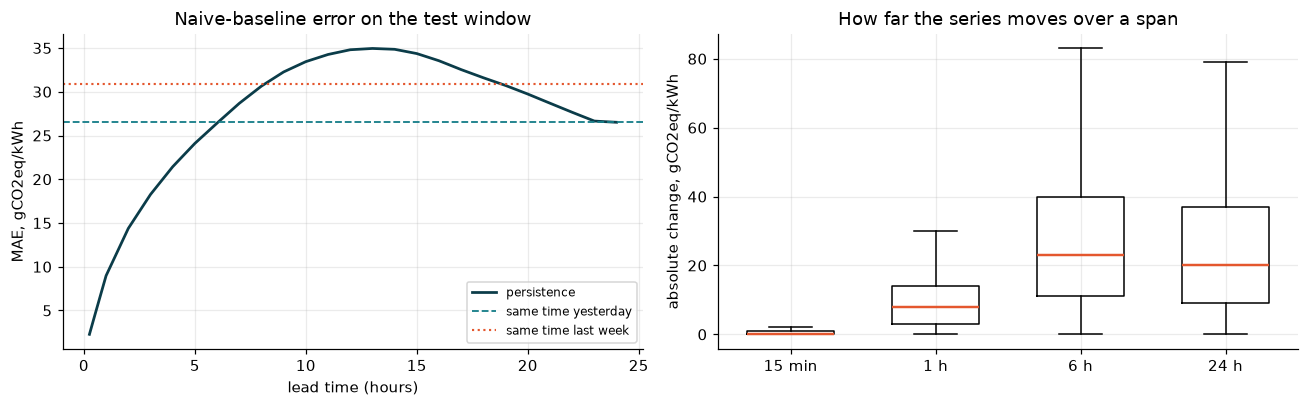

,mean absolute change (gCO2eq/kWh)
15 min,2.65
1 h,10.37
6 h,28.10
24 h,26.59


In [19]:
test_series = ci.loc[(ci.index >= protocol.test_start) & (ci.index < protocol.test_end)]
leads = np.arange(1, 97)
persistence = np.array([test_series.diff(int(lead)).abs().mean() for lead in leads])
daily_naive = np.abs(test_series - test_series.shift(96)).mean()
weekly_naive = np.abs(test_series - test_series.shift(96 * 7)).mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(leads / 4, persistence, color="#0B3C49", lw=1.8, label="persistence")
axes[0].axhline(daily_naive, color="#177E89", ls="--", lw=1.2, label="same time yesterday")
axes[0].axhline(weekly_naive, color="#E4572E", ls=":", lw=1.4, label="same time last week")
axes[0].set(
    xlabel="lead time (hours)", ylabel=f"MAE, {UNIT}",
    title="Naive-baseline error on the test window",
)
axes[0].legend(fontsize=8)

changes = pd.DataFrame({
    "15 min": ci.diff(1), "1 h": ci.diff(4), "6 h": ci.diff(24), "24 h": ci.diff(96),
}).abs()
axes[1].boxplot(
    [changes[column].dropna() for column in changes],
    tick_labels=list(changes), showfliers=False, widths=0.6,
    medianprops={"color": "#E4572E", "lw": 1.6},
)
axes[1].set(ylabel=f"absolute change, {UNIT}", title="How far the series moves over a span")
fig.tight_layout()
plt.show()

display(changes.mean().rename(f"mean absolute change ({UNIT})").to_frame())

Persistence error climbs steeply to a peak of ~35 gCO2eq/kWh at a 12-hour lead,
then *falls back* to ~26.5 at 24 hours: the daily cycle brings the series back
near where it started, so a full day ahead is easier to guess than half a day.
The "same time yesterday" line meets the curve exactly at lead 24 h because at
that lead they are the same prediction. Against a test-window standard
deviation of ~50, these naive errors are already within a factor of two of the
spread, which leaves any univariate model very little room - the ceiling is a
property of the data, not of the model.

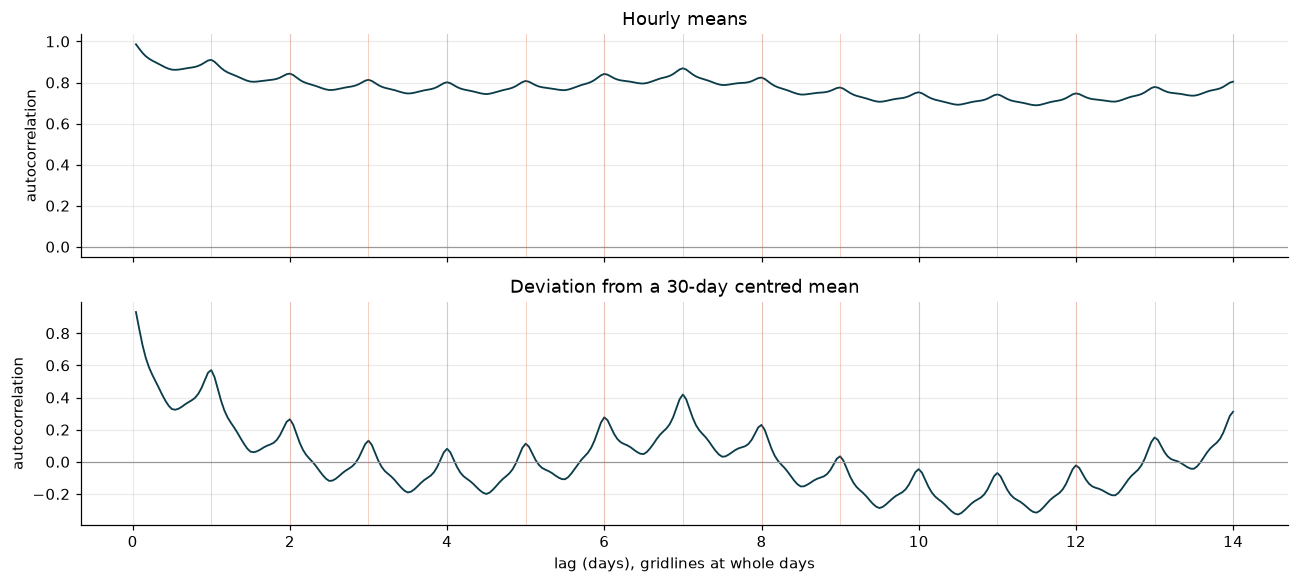

,hourly means,deviation
lag,,
1 h,0.99,0.93
12 h,0.86,0.33
24 h,0.91,0.57
36 h,0.80,0.06
48 h,0.84,0.26
7 d,0.87,0.42


In [20]:
acf_lags = np.arange(1, 24 * 14 + 1)
values = hourly.dropna()
# The raw series is so dominated by its slow level that any cycle is invisible
# in its autocorrelation; subtracting a 30-day centred mean leaves the cycles.
anomaly = (values - values.rolling(24 * 30, center=True, min_periods=1).mean()).dropna()
acf = np.array([values.autocorr(int(lag)) for lag in acf_lags])
acf_anomaly = np.array([anomaly.autocorr(int(lag)) for lag in acf_lags])

fig, axes = plt.subplots(2, 1, figsize=(12, 5.4), sharex=True)
for ax, curve, title in (
    (axes[0], acf, "Hourly means"),
    (axes[1], acf_anomaly, "Deviation from a 30-day centred mean"),
):
    ax.plot(acf_lags / 24, curve, color="#0B3C49", lw=1.2)
    ax.axhline(0, color="#999", lw=0.8)
    for day in range(1, 15):
        ax.axvline(day, color="#E4572E", lw=0.6, alpha=0.3)
    ax.set(ylabel="autocorrelation", title=title)
axes[1].set_xlabel("lag (days), gridlines at whole days")
fig.tight_layout()
plt.show()

display(pd.DataFrame({
    "hourly means": [values.autocorr(lag) for lag in (1, 12, 24, 36, 48, 24 * 7)],
    "deviation": [anomaly.autocorr(lag) for lag in (1, 12, 24, 36, 48, 24 * 7)],
}, index=["1 h", "12 h", "24 h", "36 h", "48 h", "7 d"]).rename_axis("lag"))

On the raw series the autocorrelation decays slowly and stays above 0.85 even
two weeks out - that is the persistent level, not memory of a pattern. Once the
level is removed the cycles appear: 0.57 at 24 h against 0.06 at 36 h, and a
clear weekly echo (0.42 at 7 d, higher than at 2 d). This is exactly what the
repo's `seasonal_daily` and `seasonal_weekly` baselines exploit, and it says
lagged values plus a calendar are the whole of the usable signal. Nothing in
the series announces the next swing; that would need exogenous inputs - wind
and solar generation, load, cross-border flows - which this dataset does not
carry.